In [25]:
def verdict(text):
    for line in text.splitlines():
        if line.strip().upper().startswith('VERDICT'):
            value=line.split(':',1)[1].strip().lower()
            if 'yes' in value:
                return 'yes'
            if 'no' in value:
                return 'no'
    return 'uncertain' #all other cases

In [1]:
!pip install datasets transformers accelerate qwen-vl-utils scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 32.9 MB/s eta 0:00:00:00:0100:01


In [3]:
device='cuda'
import torch
if torch.cuda.is_available():
    print(device)
else:
    print('none')

cuda


In [ ]:
from datasets import load_dataset
test_file=load_dataset('mwalmsley/euclid_strong_lens_expert_judges', 'classification',split='test')



README.md: 0.00B [00:00, ?B/s]

classification/train-00000-of-00001.parq(…):   0%|          | 0.00/87.3M [00:00<?, ?B/s]

classification/test-00000-of-00001.parqu(…):   0%|          | 0.00/22.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5876 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1476 [00:00<?, ? examples/s]

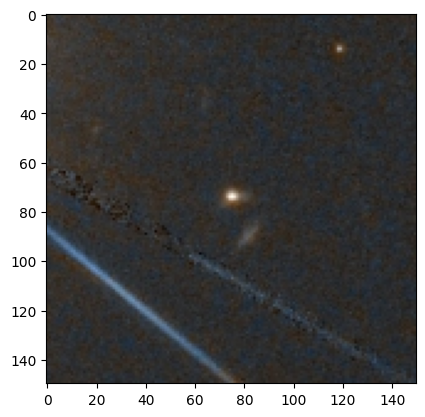

sample size: 40 positives: 20


In [19]:
import numpy as np
y_all=np.array(test_file['label'])
rng=np.random.default_rng(42)
pos=rng.choice(np.where(y_all==1)[0],size=20,replace=False)
neg=rng.choice(np.where(y_all==0)[0],size=20,replace=False)
idx=np.concatenate([pos,neg])
# print(idx)
rng.shuffle(idx) # shuffling values of idx
images=[test_file[int(i)]['image'].convert('RGB') for i in idx]
# print(idx)
import matplotlib.pyplot as plt
plt.imshow(images[0])
plt.show()
labels = y_all[idx]
print('sample size:', len(images), 'positives:', int(labels.sum()))

Dataset({
    features: ['image', 'response'],
    num_rows: 40
})
This is a pair of interacting spiral galaxies. They are actually very close together, and not merely nearby on the sky. This image does not show an instance of strong gravitational lensing.


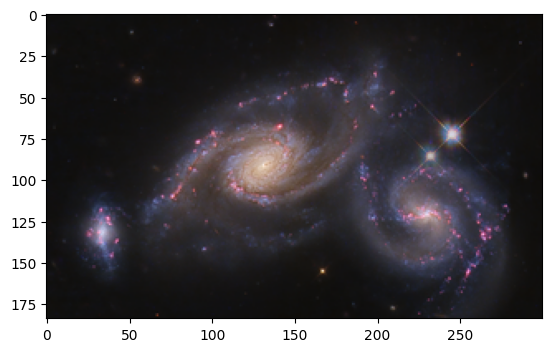

In [22]:
ref = load_dataset('Arbie333/gravitational_lensing', split='train')
print(ref)
print(ref[0]['response'])
plt.imshow(ref[0]['image'])
plt.show()

In [23]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
model_id = 'Qwen/Qwen2-VL-2B-Instruct'
vlm = Qwen2VLForConditionalGeneration.from_pretrained(model_id, torch_dtype=torch.float16, device_map='auto')
processor = AutoProcessor.from_pretrained(model_id)

PROMPT = (
    'You are assisting an astronomer reviewing telescope cutouts for strong gravitational lensing.\n\n'
    'Look at this image. Strong lensing shows clear arcs, partial Einstein rings, or multiple images '
    'of a background source.\n\n'
    'Answer in this format:\n'
    'VERDICT: yes | no | uncertain\n'
    'EVIDENCE: one or two sentences describing what you see (or do not see)\n'
    'CAUTION: one sentence about what could be confused with lensing (e.g. spiral arms, mergers)')

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

...

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [24]:
ans=[]
for img in images:
        messages = [{'role': 'user', 'content': [
        {'type': 'image', 'image': img}, {'type': 'text', 'text': PROMPT}]}]
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text], images=[img], return_tensors='pt').to(vlm.device)
        with torch.no_grad():
            out = vlm.generate(**inputs, max_new_tokens=128, do_sample=False)
        reply = processor.batch_decode(out[:, inputs.input_ids.shape[1]:], skip_special_tokens=True)[0]
        ans.append(reply)
print(ans[0])

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


VERDICT: yes
EVIDENCE: The image shows a clear arc, which is a characteristic of strong gravitational lensing. The arc is centered on a background source, and the surrounding area is distorted, indicating the presence of a strong gravitational lens.
CAUTION: The arc could also be caused by spiral arms or mergers in the background galaxy, but the presence of a clear arc is a strong indicator of strong gravitational lensing.


In [27]:
final=[verdict(i) for i in ans]
vlm_pred=np.array([1 if v=='yes' else 0 for v in final])
from sklearn.metrics import classification_report
print(classification_report(labels, vlm_pred, target_names=['not lens', 'lens']))

              precision    recall  f1-score   support

    not lens       0.00      0.00      0.00        20
        lens       0.50      1.00      0.67        20

    accuracy                           0.50        40
   macro avg       0.25      0.50      0.33        40
weighted avg       0.25      0.50      0.33        40



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


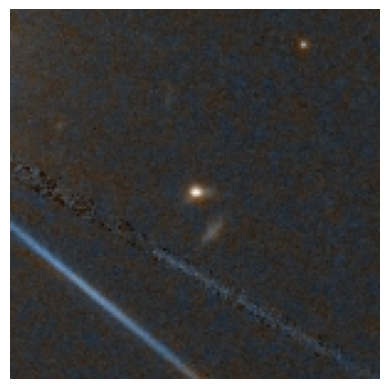

VLM said: VERDICT: yes
EVIDENCE: The image shows a clear arc, which is a characteristic of strong gravitational lensing. The arc is centered on a background source, and the surrounding area is distorted, indicating the presence of a strong gravitational lens.
CAUTION: The arc could also be caused by spiral arms or mergers in the background galaxy, but the presence of a clear arc is a strong indicator of strong gravitational lensing.


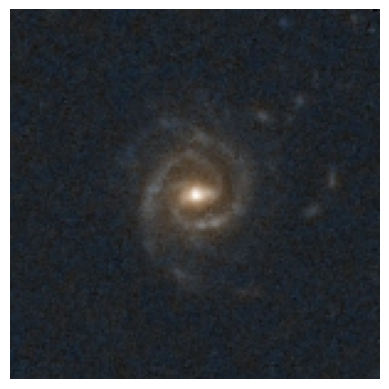

VLM said: VERDICT: yes
EVIDENCE: The image shows a clear arc, which is a characteristic of strong gravitational lensing. The arc is centered around the galaxy and extends outward, indicating the presence of a strong gravitational lens. There are no other visible features such as spiral arms or mergers that could be confused with lensing.
CAUTION: The arc could also be due to the galaxy itself, as it is a common feature of spiral galaxies. However, the arc is clearly visible and does not appear to be due to the galaxy itself.
[]


In [ ]:
halluc = [i for i in range(len(images)) if vlm_pred[i] == 1 and labels[i] == 0]
halluc1 = [i for i in range(len(images)) if vlm_pred[i] == 0 and labels[i] == 1]
for i in halluc[:2]:
    plt.imshow(images[i]); plt.axis('off'); plt.show()
    print('VLM said:', ans[i])
# print(halluc1)
for i in halluc1[:2]:
    plt.imshow(images[i]); plt.axis('off'); plt.show()
    print('VLM said:', ans[i])